In [1]:
#ETAP 1

In [2]:
import pandas as pd

In [3]:
import pandas as pd
file = r'C:\ProjektAI\spam_NLP.csv'
df = pd.read_csv(file)

# zmiana nazw kolumn
df = df.rename(columns={
    'CATEGORY': 'label',
    'MESSAGE': 'text'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5796 non-null   int64 
 1   text    5796 non-null   object
dtypes: int64(1), object(1)
memory usage: 135.8+ KB


In [4]:
df['label'].value_counts()

label
0    3900
1    1896
Name: count, dtype: int64

In [5]:
df['length'] = df['text'].apply(len)
df['length'].describe()
#rozkładu długości wiadomości


count      5796.000000
mean       2780.795204
std        6940.076914
min          36.000000
25%         664.750000
50%        1211.000000
75%        2505.250000
max      234358.000000
Name: length, dtype: float64

In [6]:
df.sample(15)

,label,text,length
5409,0,> When I get a box I don't want any of that in...,1947
5128,0,"Date: Tue, 20 Aug 2002 22:51:52 -04...",1113
5426,0,"Hi all,\n\n I have an ISA PNP card that w...",889
5162,0,"Gary Lawrence Murphy writes:\n\n> 20,000 years...",475
5517,0,\n\n\n\nHas anybody on the list installed/used...,1284
3786,0,Ben Hammersley wrote:\n\n\n\n>\n\n> On Thursda...,1883
3354,0,">>>>> ""J"" == Joseph S Barrera, <Joseph> writes...",687
3948,0,"URL: http://www.newsisfree.com/click/-6,857278...",180
4980,0,Luis Villa wrote:\n\n > So you /are/ beberg po...,229
1774,1,\n\nHello I am your hot lil horny toy.\n\n ...,830


In [56]:
print(df['text'][1473]) #SPAM
print(df['text'][3805]) #HAM
#print(df['text'][4178])



    >> Accordingly, I wrote unheader.py, which is mostly a ripoff of

    >> something someone else posted to python-dev or c.l.py within the last

    >> week or so to strip out SA-generated headers.



    Tim> Unless I've grown senile tonight, you got it from Anthony to begin

    Tim> with.  Please check it in to project, and add a short blurb to

    Tim> README.txt!



Raring to go, once I can write to CVS...



S



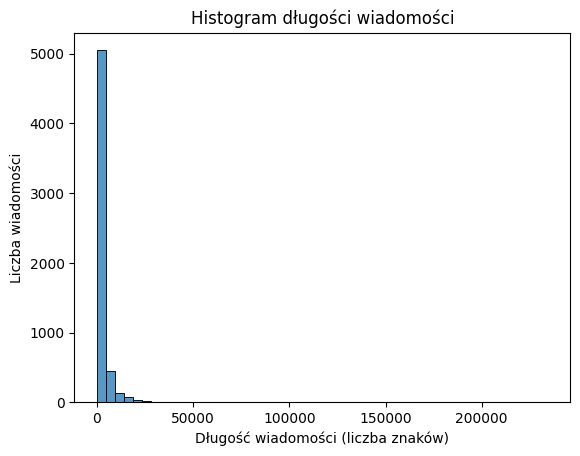

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['length'], bins=50)


plt.xlabel("Długość wiadomości (liczba znaków)")
plt.ylabel("Liczba wiadomości")
plt.title("Histogram długości wiadomości")
plt.show()

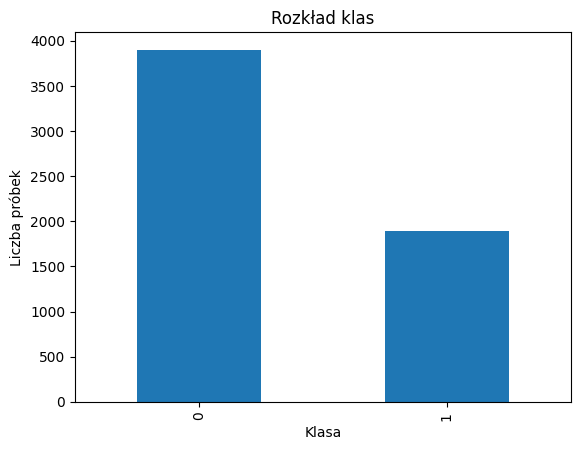

In [9]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.title("Rozkład klas")
plt.show()


In [10]:
%pip install wordcloud


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: C:\Users\contables\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


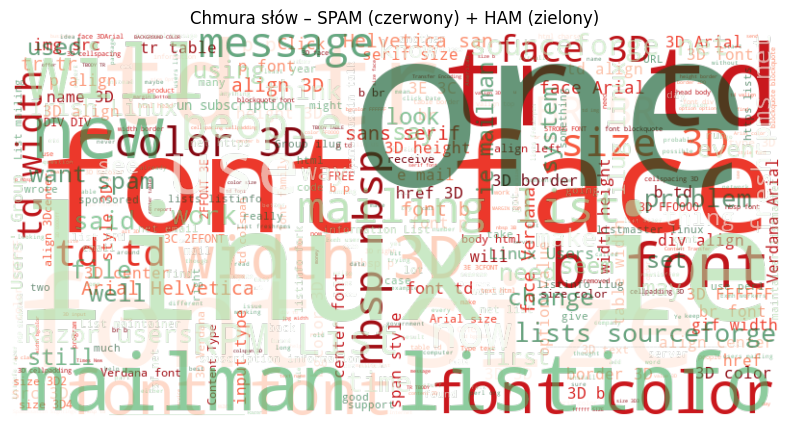

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

spam_text = " ".join(df[df['label'] == 1]['text'])
ham_text  = " ".join(df[df['label'] == 0]['text'])


wc_spam = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(spam_text)

wc_ham = WordCloud(
    width=800,
    height=400,
    background_color=None,
    mode='RGBA',
    colormap='Greens'
).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_spam, interpolation='bilinear')
plt.imshow(wc_ham, interpolation='bilinear', alpha=0.6)
plt.axis('off')
plt.title('Chmura słów – SPAM (czerwony) + HAM (zielony)')
plt.show()


In [12]:
df.duplicated().sum()


np.int64(171)

In [13]:
#ETAP 2

In [14]:
import re
text = "Ala ma 2 koty! I 4 psy #"
re.sub(r'[^a-zA-Z\s]', '', text)

'Ala ma  koty I  psy '

In [15]:
import pandas as pd 
import re 
def preprocessing_text(text): 
    text = text.lower() 
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text) 
    return (text) 
df['clean_text'] = df['text'].apply(preprocessing_text)
df.sample(10)

,label,text,length,clean_text
1822,1,\n\n\n\nARE YOU HAVING TROUBLE WITH YOUR COMPU...,3598,are you having trouble with your computer the...
780,1,<html>\n\n<CENTER>\n\n<table width=550 cellpad...,9009,html center table width cellpadding cellspaci...
4374,0,> eh? any reason why? wasn't causing any trou...,741,eh any reason why wasn t causing any trouble ...
1313,1,Look this is so hot that not only do you want ...,2920,look this is so hot that not only do you want ...
1935,0,"I think that when considering deployment, a so...",1982,i think that when considering deployment a sol...
3539,0,"> >It's official, I'm a failure. \n\n\n\nSame ...",627,it s official i m a failure same here one th ...
1728,1,WE NEED HELP. We are a 14 year old fortune 50...,867,we need help we are a year old fortune company...
4215,0,"Once upon a time, Thomas wrote :\n\n\n\n> Shou...",731,once upon a time thomas wrote should i expect ...
5628,0,"\n\nOn Thursday, August 8, 2002, at 09:05 AM,...",4655,on thursday august at am gregory sloop wrote ...
5548,0,-----BEGIN PGP SIGNED MESSAGE-----\n\nHash: SH...,1594,begin pgp signed message hash sha at pm on ro...


In [16]:
import nltk

nltk.download('stopwords')
#from nltk.corpus import stopwords
#stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\contables\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
#import nltk

#nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [18]:
import pandas as pd
file = r'C:\ProjektAI\spam_NLP.csv'
df = pd.read_csv(file)
df = df.rename(columns={
    'CATEGORY': 'label',
    'MESSAGE': 'text'
})
df

,label,text
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ..."
1,1,ATTENTION: This is a MUST for ALL Computer Use...
2,1,This is a multi-part message in MIME format.\n...
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...
4,1,This is the bottom line. If you can GIVE AWAY...
...,...,...
5791,0,"I'm one of the 30,000 but it's not working ver..."
5792,0,Damien Morton quoted:\n\n>W3C approves HTML 4 ...
5793,0,"On Mon, 2002-07-22 at 06:50, che wrote:\n\n\n\..."
5794,0,"Once upon a time, Manfred wrote :\n\n\n\n> I w..."


In [19]:
import pandas as pd 
import re 
def preprocessing_text(text): 
    text = text.lower() 
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text) 
    return (text) 
df['clean_text'] = df['text'].apply(preprocessing_text)
df.sample(10)

,label,text,clean_text
1908,0,> Gary Lawrence Murphy wrote:\n\n> >and say he...,gary lawrence murphy wrote and say hello to t...
3099,0,"\n\n >> Dunno about the other tools, but Sp...",dunno about the other tools but spamassassin ...
3838,0,I would appreciate it if you could get Gabber ...,i would appreciate it if you could get gabber ...
2824,0,"Ah, THIS is the car i've seen on discovery cha...",ah this is the car i ve seen on discovery chan...
3011,0,URL: http://diveintomark.org/archives/2002/09/...,url http diveintomark org archives html rss re...
3192,0,"Hi All,\n\n\n\nAnyone ever try connecting at 1...",hi all anyone ever try connecting at bps in li...
3233,0,"URL: http://www.newsisfree.com/click/-2,841514...",url http www newsisfree com click date t canad...
4420,0,"\n\nOn Tuesday, August 20, 2002, at 07:23 AM,...",on tuesday august at am justin mason wrote th...
1380,1,<HTML>\n\n<BODY>\n\n</head>\n\n\n\n<BODY>\n\n<...,html body head body p nbsp nbsp these are rea...
3371,0,http://www.hughes-family.org/bugzilla/show_bug...,http www hughes family org bugzilla show bug c...


In [20]:
import pandas as pd
file = r'C:\ProjektAI\spam_NLP.csv'
df = pd.read_csv(file)
df = df.rename(columns={
    'CATEGORY': 'label',
    'MESSAGE': 'text'
})
corpus = df[:1000].copy()
corpus

,label,text
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ..."
1,1,ATTENTION: This is a MUST for ALL Computer Use...
2,1,This is a multi-part message in MIME format.\n...
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...
4,1,This is the bottom line. If you can GIVE AWAY...
...,...,...
995,1,"<HTML><BODY BGCOLOR=3D""#FFFFFF"">\n\n<table wid..."
996,1,Long time no chat!\n\n\n\nHow have you been? I...
997,1,"\n\n\n\nChina's rapid economic growth, as rank..."
998,1,"<html>\n\n\n\n<body>\n\n\n\n<font size=""2"" PTS..."


In [21]:

import spacy 
from spacy.lang.en import STOP_WORDS
nlp = spacy.load('en_core_web_sm')

#pipeline przetwarzania
def preprocessing_text(text): 
    doc = nlp(text.lower())
    text = [token for token in doc if token.is_alpha] #tokenizacja 
    text = [token.lemma_ for token in text] #lematyzacja
    text = [token for token in text if token not in STOP_WORDS] #lista stop
    return text
df['clean_text'] = df['text'].apply(preprocessing_text)
df.sample(6)

,label,text,clean_text
3471,0,> [Guido]\n\n> > Perhaps more useful would be ...,"[guido, useful, tim, check, generate, training..."
4763,0,This is a multi-part message in MIME format.\n...,"[multi, message, mime, format, content, type, ..."
5594,0,I told AT&T to get lost after they wanted $$$ ...,"[I, tell, lose, want, change, service, address..."
2329,0,"URL: http://www.newsisfree.com/click/-2,842491...","[url, date, local, library]"
4877,0,"On Tue, Aug 13, 2002 at 01:40:21AM +0200, Paul...","[tue, aug, paul, linehan, write, rick, moen, é..."
694,1,"Obtain a prosperous future, money earning powe...","[obtain, prosperous, future, money, earn, powe..."


In [22]:
#ETAP 3 

In [23]:
y = df['label']
y

0       1
1       1
2       1
3       1
4       1
       ..
5791    0
5792    0
5793    0
5794    0
5795    0
Name: label, Length: 5796, dtype: int64

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
X = df['clean_text'].apply(lambda x: ' '.join(x))

vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_count = vectorizer.fit_transform(X)
print(X_count)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 427983 stored elements and shape (5796, 5000)>
  Coords	Values
  (0, 1090)	1
  (0, 2303)	1
  (0, 3559)	2
  (0, 2613)	1
  (0, 3331)	1
  (0, 4977)	1
  (0, 2033)	1
  (0, 1665)	1
  (0, 1902)	1
  (0, 4062)	1
  (0, 2726)	1
  (0, 2967)	1
  (0, 2503)	1
  (0, 2079)	4
  (0, 2199)	1
  (0, 3631)	1
  (0, 3906)	1
  (0, 2885)	1
  (0, 1442)	1
  (0, 2578)	1
  (0, 3248)	1
  (0, 1005)	1
  (0, 3982)	1
  (0, 1778)	1
  (0, 3144)	1
  :	:
  (5795, 191)	1
  (5795, 4942)	1
  (5795, 4710)	1
  (5795, 3290)	3
  (5795, 1219)	3
  (5795, 946)	1
  (5795, 2977)	1
  (5795, 3414)	1
  (5795, 4249)	1
  (5795, 3731)	1
  (5795, 603)	1
  (5795, 2320)	1
  (5795, 4938)	1
  (5795, 3298)	1
  (5795, 1700)	6
  (5795, 229)	1
  (5795, 1515)	1
  (5795, 1518)	1
  (5795, 4939)	1
  (5795, 534)	1
  (5795, 4881)	1
  (5795, 3871)	1
  (5795, 535)	1
  (5795, 4108)	1
  (5795, 1820)	2


In [25]:
#2 metoda 
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X_tfidf = tfidf_vectorizer.fit_transform(X)

print(X_tfidf)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 430561 stored elements and shape (5796, 5000)>
  Coords	Values
  (0, 1088)	0.11530943046245272
  (0, 2310)	0.10571174555827502
  (0, 3546)	0.2006081069968321
  (0, 2616)	0.0960447081093993
  (0, 3318)	0.09221020635094322
  (0, 4976)	0.07766708385739872
  (0, 2042)	0.0815814078468121
  (0, 1670)	0.07112309843959622
  (0, 1912)	0.06753293328033065
  (0, 4064)	0.1250670227055033
  (0, 2722)	0.13359170758274125
  (0, 2947)	0.0700409565259168
  (0, 2506)	0.14216090656847216
  (0, 2088)	0.3478933720633838
  (0, 2207)	0.1395962266281858
  (0, 3620)	0.14693274723292438
  (0, 3905)	0.10244607387311172
  (0, 2874)	0.12615806833319634
  (0, 1439)	0.14816542561391674
  (0, 2580)	0.12868565829869597
  (0, 3235)	0.13334818761804831
  (0, 1000)	0.10275537351350422
  (0, 3983)	0.08680085029410675
  (0, 1787)	0.06880174008244219
  (0, 3130)	0.12748951593478638
  :	:
  (5795, 186)	0.11276445794776914
  (5795, 4940)	0.06486850703666794
  (5795

In [26]:
import spacy 
from spacy.lang.en import STOP_WORDS
nlp = spacy.load('en_core_web_sm')

#pipeline przetwarzania
def preprocessing_text(text): 
    text = text.strip().lower()
    doc = nlp(text.lower())
    tokens = [token for token in doc if token.is_alpha] #tokenizacja 
    lemmas = [token.lemma_ for token in tokens] #lematyzacja
    no_stop = [word for word in lemmas if word not in STOP_WORDS] #lista stop
    no_single = [word for word in no_stop if len(word)>1]
    return " ".join(no_single)
df['clean_text'] = df['text'].apply(preprocessing_text)


In [27]:
#gestosc macierzy 
print("TF-IDF – liczba cech:", X_tfidf.shape[1])
print("Gęstość macierzy:", X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))



TF-IDF – liczba cech: 5000
Gęstość macierzy: 0.014857177363699103


In [28]:
#Najważniejsze słowa dla każdej klas
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tfidf, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
import numpy as np

def get_top_features(vectorizer, X, top_n=20):
    feature_names = np.array(vectorizer.get_feature_names_out())
    mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
    top_indices = mean_tfidf.argsort()[::-1][:top_n]
    return feature_names[top_indices]


In [30]:
top_words = get_top_features(tfidf_vectorizer, X_tfidf, top_n=20)
print("Najważniejsze słowa (TF-IDF):")
print(top_words)

Najważniejsze słowa (TF-IDF):
['list' 'br' 'td' 'use' 'url' 'date' 'url date' 'email' 'write' 'font'
 'content' 'mailing' 'user' 'linux' 'mail' 'work' 'message' 'free' 'time'
 'like']


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
)
print("TRAIN:", X_train.shape, y_train.shape)
print("TEST:", X_test.shape, y_test.shape)


TRAIN: (4636,) (4636,)
TEST: (1160,) (1160,)


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print("TRAIN:")
print(y_train.value_counts(normalize=True))
print("\nTEST:")
print(y_test.value_counts(normalize=True))

# TF-IDF Vectorizer - dopasowanie do danych treningowych
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Przekształcenie danych testowych tym samym wektorizerem
X_test_tfidf = tfidf_vectorizer.transform(X_test)



TRAIN:
label
0    0.672778
1    0.327222
Name: proportion, dtype: float64

TEST:
label
0    0.673276
1    0.326724
Name: proportion, dtype: float64


In [33]:
RANDOM_STATE = 50

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)


In [34]:
#ETAP 5 i 6

In [35]:
# Importy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd



In [36]:
# Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


=== Naive Bayes ===
              precision    recall  f1-score   support

           0     0.9762    0.9962    0.9861       781
           1     0.9917    0.9499    0.9704       379

    accuracy                         0.9810      1160
   macro avg     0.9839    0.9730    0.9782      1160
weighted avg     0.9812    0.9810    0.9809      1160

Confusion Matrix:
 [[778   3]
 [ 19 360]]


In [37]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=50)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9835    0.9949    0.9892       781
           1     0.9892    0.9657    0.9773       379

    accuracy                         0.9853      1160
   macro avg     0.9864    0.9803    0.9832      1160
weighted avg     0.9854    0.9853    0.9853      1160

Confusion Matrix:
 [[777   4]
 [ 13 366]]


In [38]:
# Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', random_state=50)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


=== SVM ===
              precision    recall  f1-score   support

           0     0.9936    0.9923    0.9930       781
           1     0.9842    0.9868    0.9855       379

    accuracy                         0.9905      1160
   macro avg     0.9889    0.9896    0.9892      1160
weighted avg     0.9905    0.9905    0.9905      1160

Confusion Matrix:
 [[775   6]
 [  5 374]]


In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
# Model SVM 
svm_model = SVC(kernel='linear', random_state=50)

In [40]:

param_dist = {
    'C': [0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=SVC(kernel='linear', random_state=50),
    param_distributions=param_dist,
    n_iter=6,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=50
)

random_search.fit(X_train_tfidf, y_train)

print("Najlepsze parametry:", random_search.best_params_)
print("Najlepsze F1-score w CV:", random_search.best_score_)

y_pred_svm_best = random_search.best_estimator_.predict(X_test_tfidf)
print("=== SVM po RandomizedSearchCV ===")
print(classification_report(y_test, y_pred_svm_best, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_best))



Najlepsze parametry: {'class_weight': 'balanced', 'C': 10}
Najlepsze F1-score w CV: 0.988350314861019
=== SVM po RandomizedSearchCV ===
              precision    recall  f1-score   support

           0     0.9961    0.9885    0.9923       781
           1     0.9766    0.9921    0.9843       379

    accuracy                         0.9897      1160
   macro avg     0.9864    0.9903    0.9883      1160
weighted avg     0.9898    0.9897    0.9897      1160

Confusion Matrix:
 [[772   9]
 [  3 376]]


In [41]:
#WIZUALIZACJA WYNIKÓW

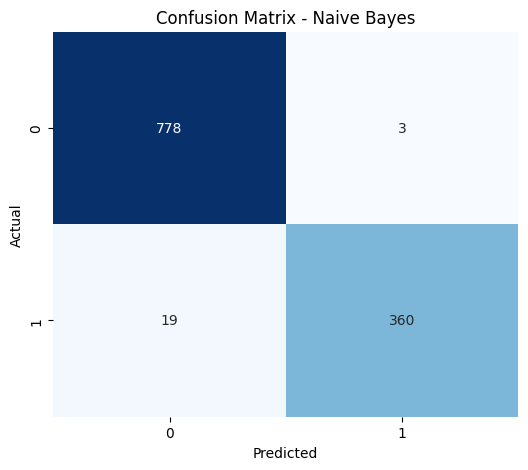

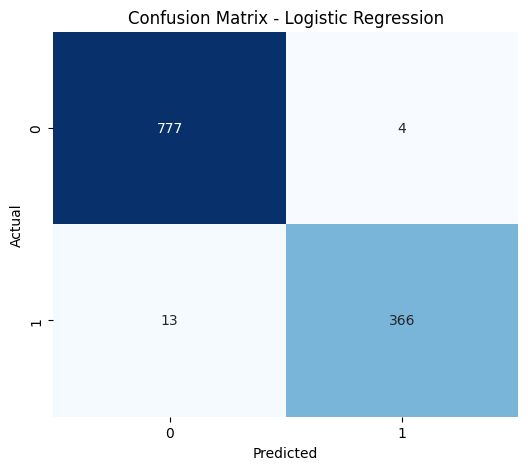

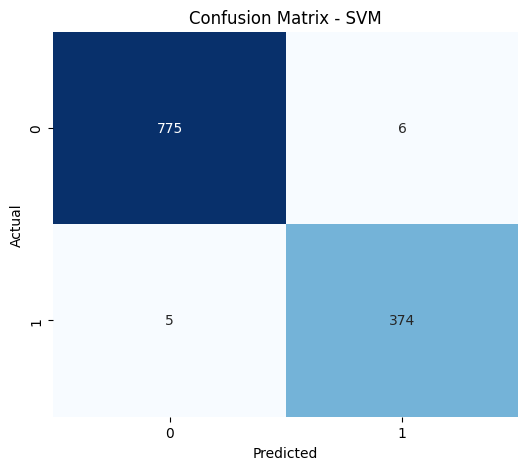

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Funkcja do rysowania heatmapy
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

plot_confusion_matrix(y_test, y_pred_svm, "SVM")


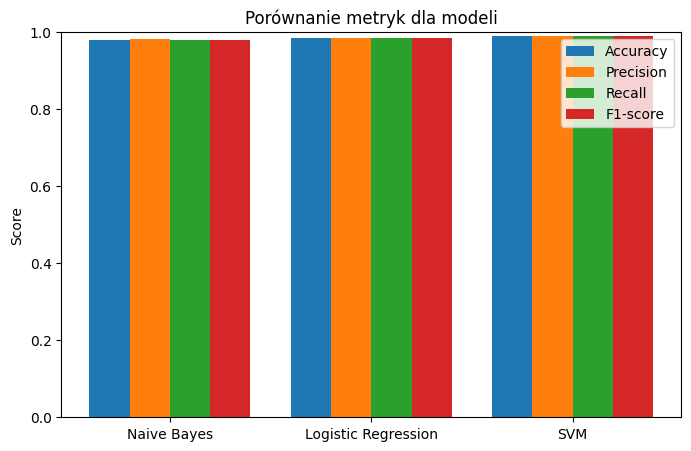

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Lista modeli i ich predykcji
models = {
    "Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm
}

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
results = {metric: [] for metric in metrics}

# Obliczanie metryk dla każdego modelu
for name, y_pred in models.items():
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred, average='weighted'))
    results["Recall"].append(recall_score(y_test, y_pred, average='weighted'))
    results["F1-score"].append(f1_score(y_test, y_pred, average='weighted'))

# Tworzenie wykresu
x = range(len(models))
width = 0.2  # szerokość słupka

plt.figure(figsize=(8,5))
for i, metric in enumerate(metrics):
    plt.bar([p + width*i for p in x], results[metric], width=width, label=metric)

plt.xticks([p + width*1.5 for p in x], models.keys())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Porównanie metryk dla modeli")
plt.legend()
plt.show()


In [44]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, digits=4)
print(report)


              precision    recall  f1-score   support

           0     0.9936    0.9923    0.9930       781
           1     0.9842    0.9868    0.9855       379

    accuracy                         0.9905      1160
   macro avg     0.9889    0.9896    0.9892      1160
weighted avg     0.9905    0.9905    0.9905      1160



In [46]:
import os
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50, stratify=y
)

#  TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# RandomizedSearchCV dla SVM 
param_dist = {
    'C': [0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=SVC(kernel='linear', random_state=50),
    param_distributions=param_dist,
    n_iter=6,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=50
)

random_search.fit(X_train_tfidf, y_train)

#  Sprawdzenie wyników 
print("Najlepsze parametry:", random_search.best_params_)
print("Najlepsze F1-score w CV:", random_search.best_score_)

y_pred_svm_best = random_search.best_estimator_.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_svm_best, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_best))

# Zapis modelu i vectorizera 
os.makedirs("models", exist_ok=True)

with open("models/vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

with open("models/model.pkl", "wb") as f:
    pickle.dump(random_search.best_estimator_, f)

print("Pliki 'vectorizer.pkl' i 'model.pkl' zapisane w folderze 'models'")


Najlepsze parametry: {'class_weight': 'balanced', 'C': 10}
Najlepsze F1-score w CV: 0.988350314861019
              precision    recall  f1-score   support

           0     0.9961    0.9885    0.9923       781
           1     0.9766    0.9921    0.9843       379

    accuracy                         0.9897      1160
   macro avg     0.9864    0.9903    0.9883      1160
weighted avg     0.9898    0.9897    0.9897      1160

Confusion Matrix:
 [[772   9]
 [  3 376]]
Pliki 'vectorizer.pkl' i 'model.pkl' zapisane w folderze 'models'


In [52]:
from predict import predict_spam
from text_processing import preprocessing_text
